An off-lattice particle-cluster polydisperse tunable sequential aggregation (PTSA) algorithm by Singh and Tsotas 2022, https://doi.org/10.1016/j.ces.2021.117022  

In [278]:
import numpy as np
import numba

In [279]:
@numba.njit
def ptsa(Np, mean_rp, rel_std_rp, Df, k, max_search_num, rng):
    """
    Polydisperse tunable sequential aggregation (PTSA) method for generating fractal-like aggregate.
    Monomer radius follows a normal distribution with specified mean and standard deviation.
    The algorithms might fail depending on the combination of (k, Df).
    N.Moteki tested only k=0.95, and Df= 2.35~2.95, 

    Inner distance-check loop uses early exit on overlap detection,
    avoiding full O(ip) distance scans for rejected candidates.

    ==== Input parameters ===
    Np: number of monomers
    mean_rp: mean of the normal distribution of the monomer radius
    rel_std_rp: relative standard deviation of the normal distrituion of the monomer radius 
    Df: fractal dimension
    k: fractal prefactor
    max_search_num: maximum number of iteration for searching a location of each monomer attached onto the surface of an aggregate (= 20000000)
    rng: random number generator constructed by the numpy.random.default_rng()

    === Output variables ===
    Np_final: number of monomers in the generated aggregate. If the aggregate generation failed, Np_final < Np.
    xp: (x,y,z) coordinate of the center of individual monomers relative to the centroid of the aggregate. 2D of shape= (Np,3).
    rp: radii of individual monomers. 1D array of size= Np.
    V: volume of the aggregate.
    Rve: volume-equivalent radius of the aggregate.
    Rg: gyration radius of aggregate.
    eps_agg: porosity of the aggregate calculated using the gyration method.

    reference: 
    Singh and Tsotas 2022, https://doi.org/10.1016/j.ces.2021.117022  

    Coded and tested by Nobuhiro Moteki, 2023-Jan-29th
    Optimized by Claude (early-exit distance loop), 2026-Mar-09th
    """

    #torelance of inter-monomer separation between attached monomers
    tol = 0.001+(2.95-Df)*0.0033 #tol= 0.001 @ Df=2.95, tol=0.003 @ Df=2.35

    # box muller method for genarating standard normal random vairable snv
    u1= rng.random(size= Np)
    u2= rng.random(size= Np)
    r= np.sqrt(-2.0*np.log(u1))
    theta= 2.0*np.pi*u2
    snv= r*np.cos(theta) # random number from the standard normal distribution

    # enforce outliers beyond 2 sigma to the boundary values
    for i, val in enumerate(snv):
        if val < -2:
            snv[i]= -2
        elif val > 2:
            snv[i]= 2

    rp= mean_rp*rel_std_rp*snv + mean_rp # radius of indivitual monomers (normal distribution) 
    density = 1.0 # monomer bulk density
    mp= (4*np.pi/3)*density*rp**3  # mass of individual monomers
    mp3t= np.broadcast_to(mp, (3,Np))
    mp3= mp3t.transpose() 
    xp= np.zeros((Np,3)) # 3D coordinates (x,y,z) of the centers of Np monomers
    minimum_separation= mean_rp*1e-6  # tolerance of intermonomer surface separation [um]

    xp[0,0],xp[0,1],xp[0,2]= 0.0,0.0,0.0
    # generate random point on a unit surface
    phi= rng.random()*2*np.pi
    u= rng.random()*2-1.0
    sqrt1mu2= np.sqrt(1-u**2)
    ux,uy,uz= sqrt1mu2*np.cos(phi), sqrt1mu2*np.sin(phi), u   # random position on the surface of the unit sphere
    R= rp[0]+rp[1]+minimum_separation # distance between the centers of 1st and 2nd monomers
    xp[1,0],xp[1,1],xp[1,2]= R*ux, R*uy, R*uz  # center position of 2nd monomer
    xp[0:2,:]= xp[0:2,:]- np.sum(mp3[0:2,:]*xp[0:2,:],axis=0)/np.sum(mp[0:2]) # shift the centroid to the origin 

    Np_final=0
    for ip in range(2,Np):
        n= ip+1 # index of monomer (3,...,Np)
        Rpn= rp[ip] # radius of n-th monomer
        if n <= k**(3/(3-Df)):
            Df_tuned= 3
        else:
            Df_tuned= Df*(np.log(Np)/np.log(Np/k))  # Step 4. Compute tuned fractal dimension (at k=1) from the actual fractal dimensiton and prefactor (Df, k)
        R2= (n**2*Rpn**2/(n-1))*n**(2/Df_tuned)- (n*Rpn**2/(n-1))- n*Rpn**2*(n-1)**(2/Df_tuned)
        R= np.sqrt(R2)

        #maximum_separation= mean_rp*tol
        maximum_separation= mean_rp*tol*(1 + 5*(ip/Np)*(2.95-Df)/0.6)  # Np and Df dependent tuning for accerelation

        attached_cond= False
        for i_search in range(max_search_num):

            phi= rng.random()*2*np.pi
            u= rng.random()*2-1.0
            sqrt1mu2= np.sqrt(1-u*u)
            x0= R*sqrt1mu2*np.cos(phi)
            x1= R*sqrt1mu2*np.sin(phi)
            x2= R*u  # candidate center location of n-th monomer

            # Early-exit overlap and proximity check.
            # Iterates monomers one by one; breaks immediately on overlap (avoids full O(ip) scan).
            overlapping= False
            proximate= False
            for j in range(ip):
                dx= xp[j,0]-x0
                dy= xp[j,1]-x1
                dz= xp[j,2]-x2
                surf_dist= np.sqrt(dx*dx+dy*dy+dz*dz)-(rp[j]+Rpn)
                if surf_dist < minimum_separation:
                    overlapping= True
                    break  # early exit: overlap found, no need to check remaining monomers
                if surf_dist < maximum_separation:
                    proximate= True

            if overlapping:
                continue

            if proximate:
                attached_cond= True
                xp[ip,0]= x0
                xp[ip,1]= x1
                xp[ip,2]= x2
                xp[0:n,:]= xp[0:n,:]- np.sum(mp3[0:n,:]*xp[0:n,:],axis=0)/np.sum(mp[0:n]) # shift the centroid to the origin
                break

        Np_final=n
        if not attached_cond:
            break 
         
    if Np_final == Np:
        Rg= np.sqrt((1/np.sum(mp[:]))*np.sum(mp3[:,0]*((xp[:,0]**2+ xp[:,1]**2+ xp[:,2]**2) +3/5*rp[:]**2))) # Gyration radius
        Re= np.sqrt(5/3)*Rg # effectuve radius
        Vagg= 4*np.pi/3*Re**3 # effective volume
        V= np.sum(mp[:])/density # true volume
        Rve= np.cbrt(3*V/(4*np.pi)) # volume equivalent radius
        eps_agg= 1- V/Vagg # porosity
    else:
        Rg= 0
        Re= 0
        Vagg= 0
        V= 0
        Rve= 0
        eps_agg= 0
    
    return Np_final, xp, rp, V, Rve, Rg, eps_agg

In [280]:
### pre-execution of ptsa for njit compilation (User should not edit this cell) ### 

mean_rp = 0.02 # mean monomer radius [um]  (user input)
rel_std_rp = 0.1 # relative standard deviation of monomer radius [-]  (user input)
Df =2.9 # fractal dimension (Df< 2.95)
k =0.9 # fractal prefactor (k<= 0.95)
tol = 0.003 # tolerance of intermonomer surface separation relative to the mean monomer radius
max_search_num= 2000000

Np=20
rng = np.random.default_rng()
Np_final, xp, rp, V, Rve, Rg, eps_agg = ptsa(Np, mean_rp, rel_std_rp, Df, k, max_search_num, rng)

In [281]:
### User should edit this cell ###

mean_rp = 0.015 # mean monomer radius [um]  
rel_std_rp = 0.1 # relative standard deviation of monomer radius [-]  
Np = 2700 # number of monomers
Df = 2.95 # fractal dimension (Df< 2.95)
k = 0.95 # fractal prefactor (k<= 0.95)

meanRp=0.015um_rstdRp=0.10_k=0.950_Df=2.95_Np=02700_Rve=0.210um_Rg=0.228um_epsagg=0.637.ptsa generated!
  Figure saved: ./generated_agg_files/meanRp=0.015um_rstdRp=0.10_k=0.950_Df=2.95_Np=02700_Rve=0.210um_Rg=0.228um_epsagg=0.637.jpg


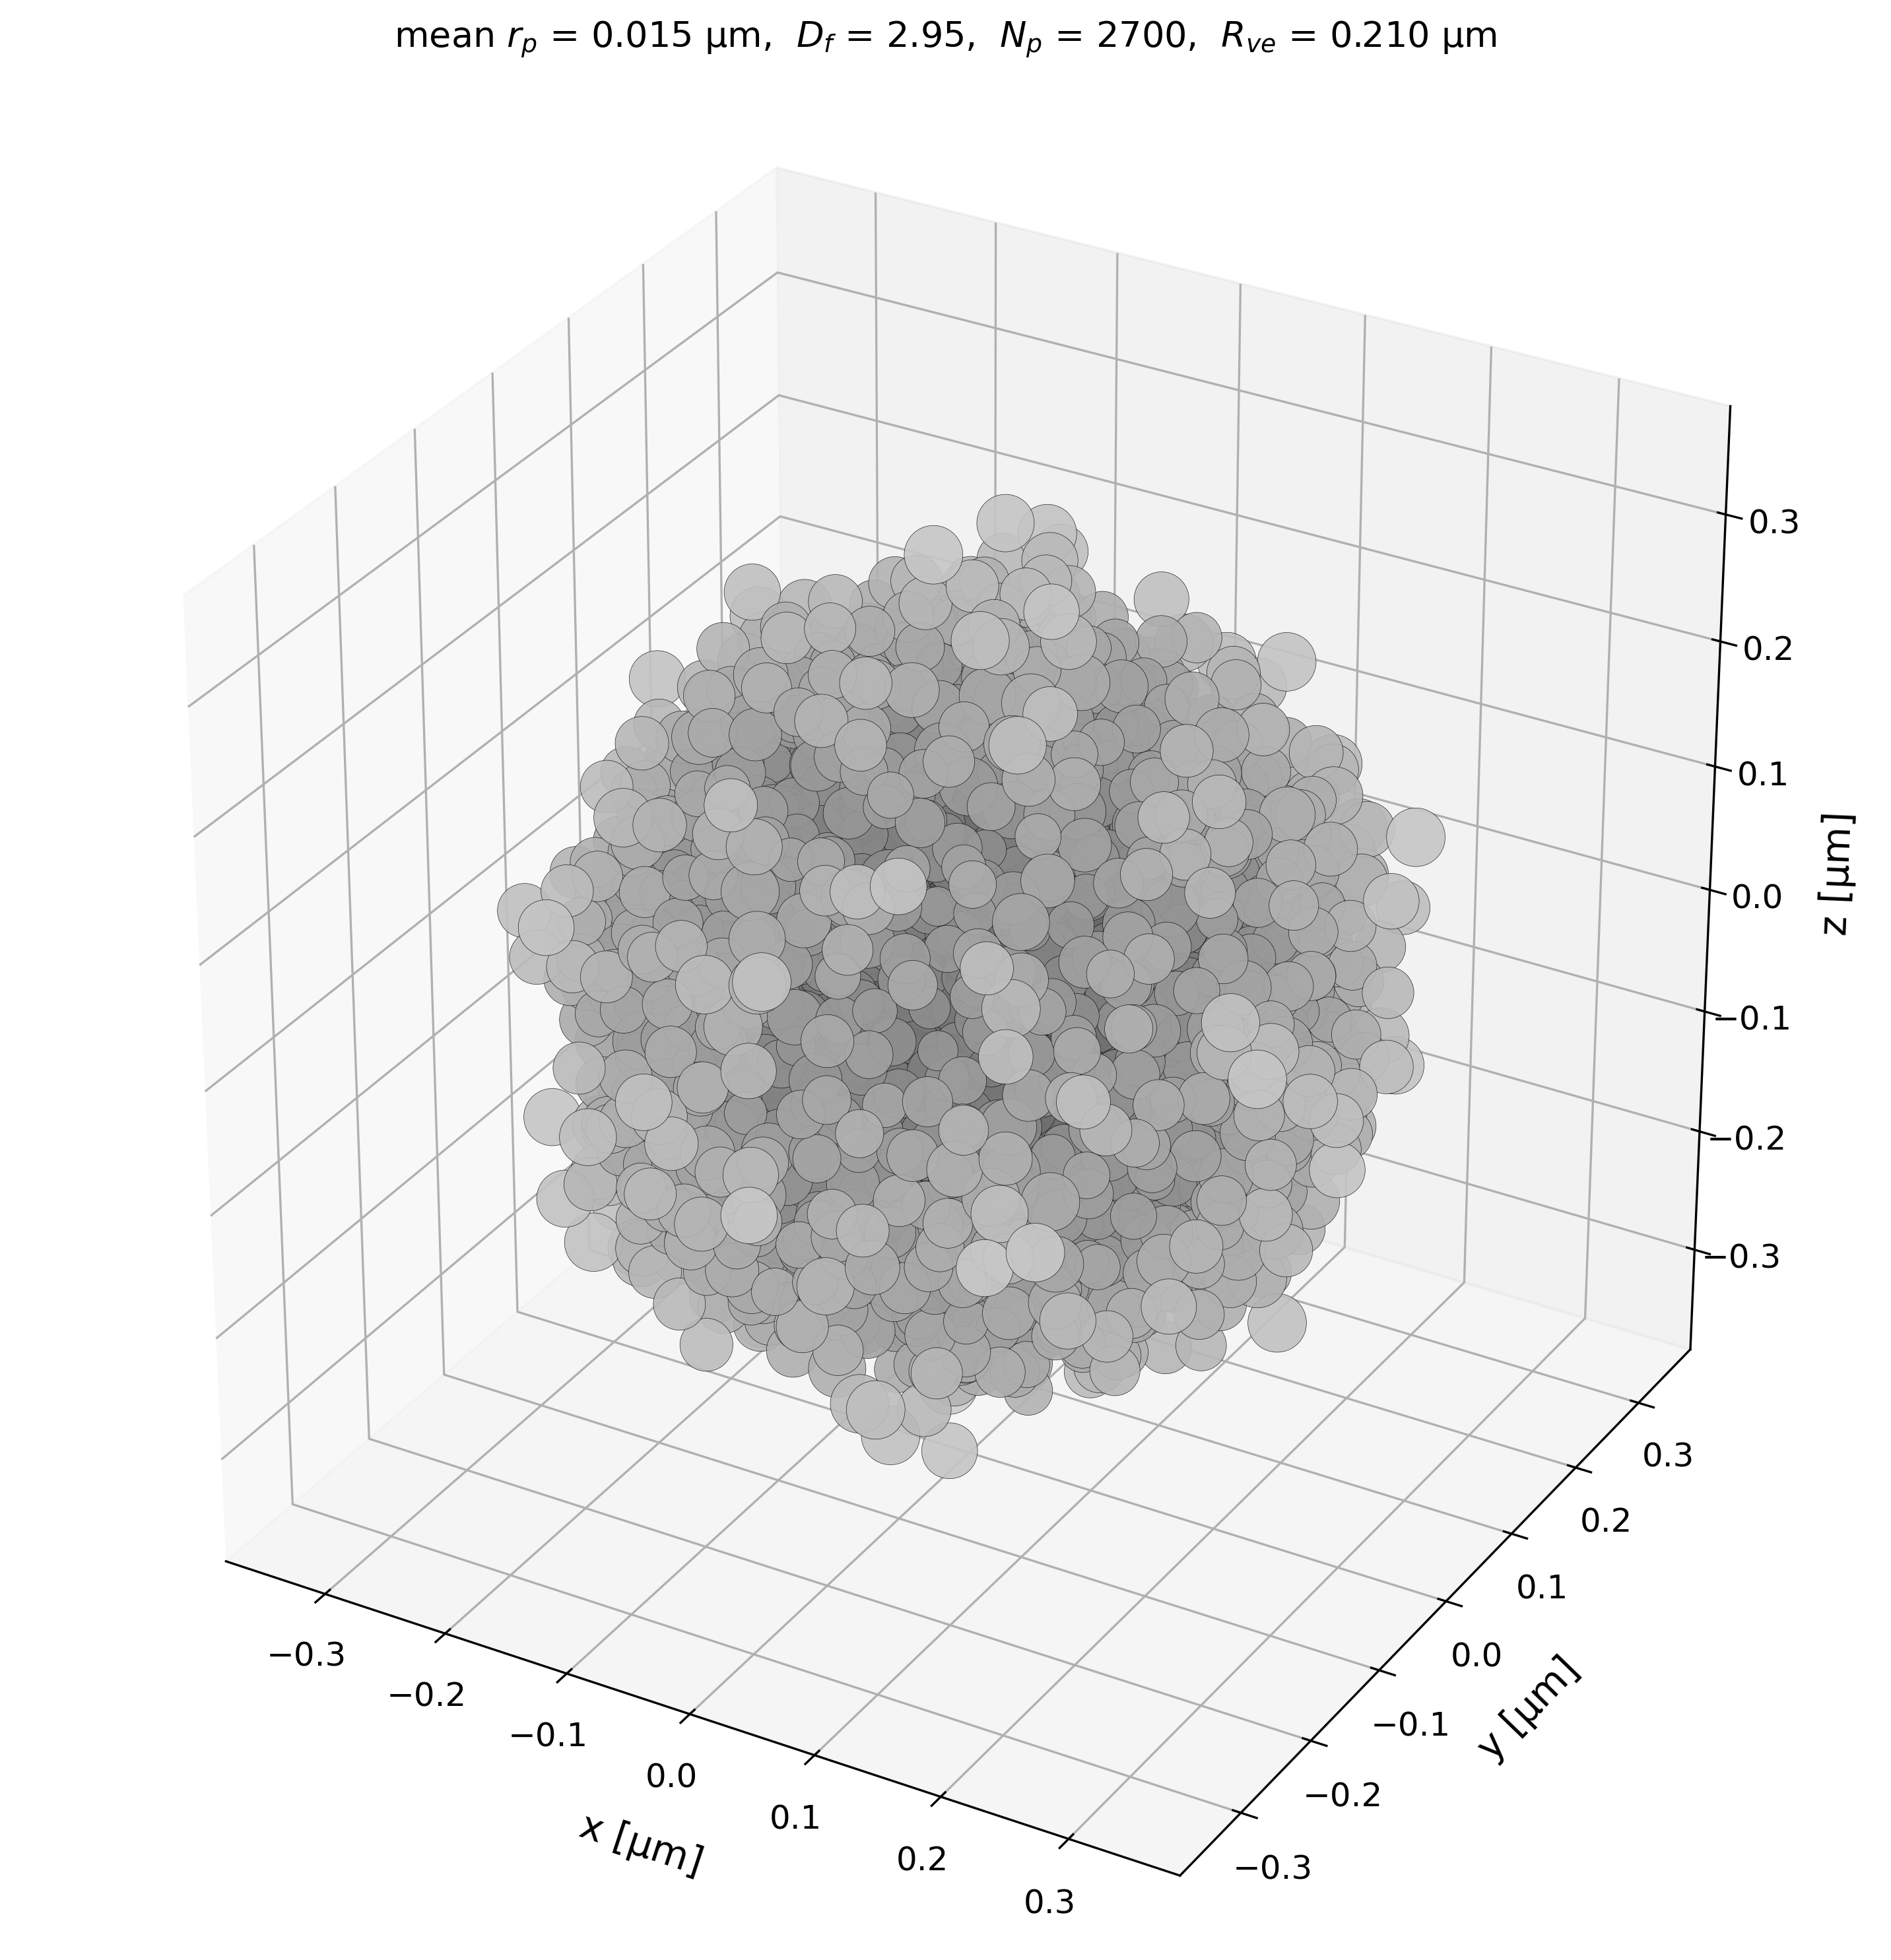

In [ ]:
### execution of the njitted ptsa ###

max_search_num = 100_000_000

rng = np.random.default_rng()

Np_final, xp, rp, V, Rve, Rg, eps_agg = ptsa(Np, mean_rp, rel_std_rp, Df, k, max_search_num, rng)

if Np_final != Np:
    print(f"Aggregate generation FAILED: Np_final={Np_final} (requested Np={Np})")
else:
    ofname = "meanRp={:5.3f}um_rstdRp={:4.2f}_k={:5.3f}_Df={:4.2f}_Np={:05d}_Rve={:5.3f}um_Rg={:5.3f}um_epsagg={:5.3f}.ptsa".format(
        mean_rp, rel_std_rp, k, Df, Np, Rve, Rg, eps_agg)
    print(ofname + " generated!", flush=True)

    with open("./generated_agg_files/" + ofname, 'w') as f:
        for ip in range(Np):
            line = "{:13.7e}  {:13.7e}  {:13.7e}  {:13.7e}".format(
                xp[ip, 0], xp[ip, 1], xp[ip, 2], rp[ip])
            f.write(line + '\n')

    # ---- 3D visualisation ----
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import proj3d
    from matplotlib.colors import Normalize

    save_dpi = 300
    fig = plt.figure(figsize=(10, 10), dpi=save_dpi)
    ax = fig.add_subplot(111, projection='3d')

    # Equal axis limits centred on the aggregate
    max_half_range = np.max(np.ptp(xp, axis=0)) / 2
    mid = np.mean(xp, axis=0)
    pad = max_half_range * 1.1 + rp.max()
    ax.set_xlim(mid[0] - pad, mid[0] + pad)
    ax.set_ylim(mid[1] - pad, mid[1] + pad)
    ax.set_zlim(mid[2] - pad, mid[2] + pad)
    ax.set_box_aspect([1, 1, 1])

    # Draw once to establish the 3D projection matrix and layout
    fig.canvas.draw()

    # Compute exact scale: data units -> display points.
    M = ax.get_proj()
    ref = pad
    x0, y0, _ = proj3d.proj_transform(mid[0],       mid[1],       mid[2], M)
    x1, y1, _ = proj3d.proj_transform(mid[0] + ref, mid[1],       mid[2], M)
    x2, y2, _ = proj3d.proj_transform(mid[0],       mid[1] + ref, mid[2], M)

    p0 = np.array(ax.transData.transform([x0, y0]))
    p1 = np.array(ax.transData.transform([x1, y1]))
    p2 = np.array(ax.transData.transform([x2, y2]))

    pix_per_unit_x = np.hypot(p1[0] - p0[0], p1[1] - p0[1]) / ref
    pix_per_unit_y = np.hypot(p2[0] - p0[0], p2[1] - p0[1]) / ref
    pix_per_unit   = (pix_per_unit_x + pix_per_unit_y) / 2
    pts_per_unit   = pix_per_unit * (72.0 / save_dpi)     # pixels -> points

    # Marker area = π r² in points², with x4 empirical correction
    s = 4.0 * np.pi * (rp * pts_per_unit) ** 2

    # Greyscale colour: dark grey at centre, light grey at outer shell
    # Clamp to [0.2, 0.8] to avoid pure black / pure white
    dist = np.sqrt(np.sum(xp ** 2, axis=1))
    norm = Normalize(vmin=dist.min(), vmax=dist.max())
    grey_values = 0.2 + 0.6 * norm(dist)   # range [0.2, 0.8]
    colors = plt.cm.gray(grey_values)

    ax.scatter(xp[:, 0], xp[:, 1], xp[:, 2],
               s=s, c=colors, alpha=0.9,
               edgecolors='k', linewidths=0.15, depthshade=True)

    # Axis labels and tick font sizes
    ax.set_xlabel('x [μm]', fontsize=14, labelpad=10)
    ax.set_ylabel('y [μm]', fontsize=14, labelpad=10)
    ax.set_zlabel('z [μm]', fontsize=14, labelpad=10)
    ax.tick_params(axis='both', labelsize=12)

    # Title with subscript notation
    ax.set_title(
        f'mean $r_p$ = {mean_rp:.3f} μm,  '
        f'$D_f$ = {Df:.2f},  '
        f'$N_p$ = {Np},  '
        f'$R_{{ve}}$ = {Rve:.3f} μm',
        fontsize=13, pad=15)

    plt.tight_layout()

    # Save as JPEG
    figpath = "./generated_agg_files/" + ofname.replace('.ptsa', '.jpg')
    fig.savefig(figpath, dpi=save_dpi, format='jpeg',
                bbox_inches='tight', pil_kwargs={'quality': 95})
    print(f"  Figure saved: {figpath}")

    plt.show()